# 05b — Phase 3a Controls: Capacity Competition with Multiple Ablation Sets

Validates whether the Phase 3a 'capacity competition' result (ablating language features releases reasoning features at L17) survives when we restrict the ablation set to manually-validated language features.

**Five variants run for every language, side by side, on the same 50 dev problems:**
1. **CURATED** — features manually labeled `LANG-<target>` on Neuronpedia (per `docs/neuronpedia_review.md`)
2. **CONFIRMED** — only the Phase 2b causally-validated LANGUAGE features (en=5, zh=3, es=3, sw=2, bn=0)
3. **BASELINE** — exact Phase 3a set (the 20 originally ablated, for comparability)
4. **RANDOM** — k random features per language (matched count)
5. **TOP-A** — top-k Method-A monolinguality features (no causal filter; Deng-style)

For each variant we measure the same thing as Phase 3a: distribution of Δ(SAE feature activation at L17) for the 21 reasoning candidates between clean and ablated forward passes, plus headline 'feature 96 was dormant → active' check.

Forward-only, no generation. Estimated time: ~5 min/variant × 5 variants = ~25 min on H100; ~45 min on A100.

## 0. Setup

In [1]:
import os
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = 'https://github.com/kvrancic/nlp-project.git'

if IN_COLAB:
    REPO_DIR = '/content/nlp-project'
    if not Path(REPO_DIR).exists():
        get_ipython().system('git clone {REPO_URL} {REPO_DIR}')
    else:
        get_ipython().system('cd {REPO_DIR} && git pull --ff-only')
    os.chdir(REPO_DIR)
    get_ipython().system("pip install -q 'numpy>=2.0' -e .")
else:
    REPO_DIR = os.getcwd()  # PI/local: cwd is the repo root

for _mod_name in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_mod_name]

if IN_COLAB:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    Path('.env').write_text(f'HF_TOKEN={os.environ["HF_TOKEN"]}\n')
else:
    from dotenv import load_dotenv
    load_dotenv()
    assert os.environ.get('HF_TOKEN'), 'HF_TOKEN missing in .env at repo root'

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_RESULTS = Path('/content/drive/MyDrive/nlp-project-results')
        DRIVE_RESULTS.mkdir(exist_ok=True, parents=True)
    except Exception:
        DRIVE_RESULTS = None
else:
    DRIVE_RESULTS = None

In [2]:
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import wilcoxon

from src.config import (
    TARGET_LANGUAGES, SAE_SUBSET_LAYERS, SAE_WIDTH_16K, RESULTS_DIR, MODEL_ID,
)
from src.data import load_mgsm
from src.model import load_saes_at_layers, get_decoder_layers
from src.intervention import directional_ablation, get_sae_decoder_directions
from src.extraction import encode_activations_through_sae

torch.manual_seed(0); np.random.seed(0)
PRIMARY_LAYER = 17
N_DEV = 50

mkdir -p failed for path /home/ubuntu/.config/matplotlib: [Errno 13] Permission denied: '/home/ubuntu/.config/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-krvt44ni because there was an issue with the default path (/home/ubuntu/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. **EDIT THIS CELL** — Manual review verdicts from `docs/neuronpedia_review.md`

After completing the Neuronpedia spot-check, paste the features marked `LANG-<target>` here.
If a language has zero matches (e.g. bn might end up empty), leave its list `[]`. The variant
for that language will simply be skipped in the CURATED run.

In [3]:
# Features the human reviewer marked LANG-<target> on Neuronpedia.
# Empty by default — fill in after running through docs/neuronpedia_review.md.
LANGUAGE_CURATED = {
    'en': [],
    'zh': [],
    'es': [],
    'bn': [],
    'sw': [],
}

for lang, feats in LANGUAGE_CURATED.items():
    print(f'  {lang}: {len(feats)} curated LANG features = {feats}')

  en: 0 curated LANG features = []
  zh: 0 curated LANG features = []
  es: 0 curated LANG features = []
  bn: 0 curated LANG features = []
  sw: 0 curated LANG features = []


## 2. Load model (no generation, no eager attention needed) + SAEs

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=os.environ['HF_TOKEN'])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto',
    token=os.environ['HF_TOKEN'],
)
model.eval()
DECODER_LAYERS = get_decoder_layers(model)
print(f'Model loaded. Layers: {len(DECODER_LAYERS)}')

saes = load_saes_at_layers(
    layers=SAE_SUBSET_LAYERS, width=SAE_WIDTH_16K, l0_target='medium',
)
sae17 = saes[PRIMARY_LAYER]
print(f'L17 SAE: d_sae = {sae17.cfg.d_sae}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Model loaded. Layers: 34


  Loaded SAE for layer 9 (width=16384, l0=medium)


  Loaded SAE for layer 17 (width=16384, l0=medium)


  Loaded SAE for layer 22 (width=16384, l0=medium)


  Loaded SAE for layer 29 (width=16384, l0=medium)
L17 SAE: d_sae = 16384


## 3. Build the five ablation-variant feature sets

In [5]:
phase1  = torch.load(RESULTS_DIR / 'phase1_features.pt', weights_only=False)
phase2b = torch.load(RESULTS_DIR / 'phase2_ablation.pt', weights_only=False)

intersection      = phase1['intersection_features']
top_A             = phase1['top_features_A']
reasoning_features_per_layer = phase1['reasoning_features']
confirmed_language = phase2b['confirmed_language']
best_k            = phase2b['best_k']

def select_lang_features(lang, k=best_k, layer=PRIMARY_LAYER):
    """Mirrors Phase 2b/3a selection: confirmed -> A∩B -> top-A."""
    out = list(confirmed_language[lang])
    for f in intersection[layer][lang]:
        if f not in out: out.append(f)
    for f in top_A[layer][lang]:
        if f not in out: out.append(f)
    return out[:k]

rng = np.random.default_rng(42)  # different seed from Phase 2b control to avoid same draws
n_features = sae17.cfg.d_sae

VARIANTS = {}

# (1) BASELINE: exact Phase 3a set (k=20, with all the contamination)
VARIANTS['baseline_k20'] = {l: select_lang_features(l, best_k) for l in TARGET_LANGUAGES}

# (2) CONFIRMED: only Phase 2b LANGUAGE-tagged features
VARIANTS['confirmed'] = {l: list(confirmed_language[l]) for l in TARGET_LANGUAGES}

# (3) CURATED: human-verified via Neuronpedia
VARIANTS['curated'] = {l: list(LANGUAGE_CURATED[l]) for l in TARGET_LANGUAGES}

# (4) RANDOM k=20 per language, fresh seed
VARIANTS['random_k20'] = {
    l: rng.choice(n_features, size=best_k, replace=False).tolist()
    for l in TARGET_LANGUAGES
}

# (5) TOP-A k=20 (Deng-style — pure monolinguality, no causal filter)
VARIANTS['top_A_k20'] = {l: list(top_A[PRIMARY_LAYER][l][:best_k]) for l in TARGET_LANGUAGES}

print('=== Variant feature counts per language ===')
for vname, vdict in VARIANTS.items():
    counts = {l: len(vdict[l]) for l in TARGET_LANGUAGES}
    print(f'  {vname:14s} {counts}')

=== Variant feature counts per language ===
  baseline_k20   {'en': 20, 'zh': 20, 'es': 20, 'bn': 20, 'sw': 20}
  confirmed      {'en': 5, 'zh': 3, 'es': 3, 'bn': 0, 'sw': 2}
  curated        {'en': 0, 'zh': 0, 'es': 0, 'bn': 0, 'sw': 0}
  random_k20     {'en': 20, 'zh': 20, 'es': 20, 'bn': 20, 'sw': 20}
  top_A_k20      {'en': 20, 'zh': 20, 'es': 20, 'bn': 20, 'sw': 20}


## 4. Forward-collect + ablation hook (matches notebook 05 exactly)

In [6]:
def make_ablation_hook(directions: torch.Tensor, input_length: int):
    pos = input_length - 1
    def hook(module, input, output):
        if isinstance(output, torch.Tensor):
            hs = output
            is_tuple = False
        else:
            hs = output[0]
            is_tuple = True
        if hs.dim() == 3 and hs.shape[1] > pos:
            hs[:, pos, :] = directional_ablation(hs[:, pos, :], directions)
        if is_tuple:
            return (hs,) + output[1:]
        return hs
    return hook

def forward_collect_l17(prompt: str, ablation_dirs: torch.Tensor = None):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    input_len = inputs['input_ids'].shape[1]
    handles = []
    if ablation_dirs is not None and len(ablation_dirs) > 0:
        handles.append(DECODER_LAYERS[PRIMARY_LAYER].register_forward_hook(
            make_ablation_hook(ablation_dirs.to(model.device), input_len)))
    try:
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True, use_cache=False)
    finally:
        for h in handles: h.remove()
    # hidden_states[0] = embeddings, hidden_states[i+1] = output of layer i
    return out.hidden_states[PRIMARY_LAYER + 1][:, -1, :].cpu().float()

REASONING_FEATS_L17 = reasoning_features_per_layer[17]
if not REASONING_FEATS_L17:
    REASONING_FEATS_L17 = list(range(50))  # fallback (matches nb 05)
print(f'Tracking {len(REASONING_FEATS_L17)} reasoning features at L17')

mgsm = load_mgsm(TARGET_LANGUAGES)
def make_prompt(q):
    return tokenizer.apply_chat_template(
        [{'role': 'user', 'content': q}], tokenize=False, add_generation_prompt=True,
    )

Tracking 21 reasoning features at L17


## 5. Run capacity competition for every variant

Optimization: clean residuals are identical across variants (no ablation), so we compute them once per language. Ablated residuals are recomputed per (variant, language).

In [7]:
# Step 5a: clean residuals once per language
clean_l17 = {}
for lang in TARGET_LANGUAGES:
    rs = []
    for i in tqdm(range(N_DEV), desc=f'clean {lang}'):
        prompt = make_prompt(mgsm[lang][i]['question'])
        rs.append(forward_collect_l17(prompt, ablation_dirs=None))
    clean_l17[lang] = torch.stack(rs)  # (N_DEV, 1, d_model)
    # encode through L17 SAE → reasoning-feature acts
    enc = encode_activations_through_sae(clean_l17[lang].squeeze(1), sae17)  # (N_DEV, d_sae)
    print(f'  {lang} clean encoded shape: {tuple(enc.shape)}')

clean en:   0%|          | 0/50 [00:00<?, ?it/s]

  en clean encoded shape: (50, 16384)


clean zh:   0%|          | 0/50 [00:00<?, ?it/s]

  zh clean encoded shape: (50, 16384)


clean es:   0%|          | 0/50 [00:00<?, ?it/s]

  es clean encoded shape: (50, 16384)


clean bn:   0%|          | 0/50 [00:00<?, ?it/s]

  bn clean encoded shape: (50, 16384)


clean sw:   0%|          | 0/50 [00:00<?, ?it/s]

  sw clean encoded shape: (50, 16384)


In [8]:
# Step 5b: per-variant ablated residuals + summary stats
all_results = {}

for vname, vdict in VARIANTS.items():
    print(f'\n========= variant: {vname} =========')
    variant_summary = {}
    for lang in TARGET_LANGUAGES:
        feats = vdict[lang]
        if len(feats) == 0:
            print(f'  {lang}: empty feature set — skipped')
            continue
        dirs = get_sae_decoder_directions(sae17, feats).to(model.device)
        ablt_l17 = []
        for i in tqdm(range(N_DEV), desc=f'{vname} {lang}', leave=False):
            prompt = make_prompt(mgsm[lang][i]['question'])
            ablt_l17.append(forward_collect_l17(prompt, ablation_dirs=dirs))
        ablt_l17 = torch.stack(ablt_l17).squeeze(1)
        # SAE-encode reasoning candidates
        clean_enc = encode_activations_through_sae(clean_l17[lang].squeeze(1), sae17)
        ablt_enc  = encode_activations_through_sae(ablt_l17, sae17)
        # restrict to reasoning-feature subset
        clean_r = clean_enc[:, REASONING_FEATS_L17].numpy()
        ablt_r  = ablt_enc[:, REASONING_FEATS_L17].numpy()

        rows = []
        for j, fidx in enumerate(REASONING_FEATS_L17):
            cf, af = clean_r[:, j], ablt_r[:, j]
            diff = af - cf
            if np.allclose(diff, 0):
                p = 1.0; stat = 0.0
            else:
                try:
                    stat, p = wilcoxon(af, cf)
                except ValueError:
                    stat, p = 0.0, 1.0
            rows.append({
                'feature': int(fidx),
                'mean_clean': float(cf.mean()),
                'mean_ablated': float(af.mean()),
                'mean_delta': float(diff.mean()),
                'p_value': float(p),
            })
        df = pd.DataFrame(rows)
        n_up   = int((df['mean_delta'] > 0).sum())
        n_down = int((df['mean_delta'] < 0).sum())
        n_sig  = int((df['p_value'] < 0.05).sum())
        # Headline check: feature 96
        f96 = df[df.feature == 96]
        f96_str = ''
        if not f96.empty:
            row = f96.iloc[0]
            f96_str = f' | f=96: clean={row.mean_clean:.3f} ablated={row.mean_ablated:.3f} Δ={row.mean_delta:+.3f} p={row.p_value:.3g}'
        print(f'  {lang}: {n_up} ↑, {n_down} ↓, {n_sig} sig of {len(df)}{f96_str}')
        variant_summary[lang] = df
    all_results[vname] = variant_summary
    torch.save({'variants': all_results, 'curated_input': LANGUAGE_CURATED},
               RESULTS_DIR / 'phase3a_controls_partial.pt')


========= variant: baseline_k20 =========


baseline_k20 en:   0%|          | 0/50 [00:00<?, ?it/s]

  en: 9 ↑, 12 ↓, 21 sig of 21 | f=96: clean=0.000 ablated=2577.084 Δ=+2577.084 p=1.78e-15


baseline_k20 zh:   0%|          | 0/50 [00:00<?, ?it/s]

  zh: 12 ↑, 9 ↓, 20 sig of 21 | f=96: clean=0.000 ablated=2500.513 Δ=+2500.513 p=1.78e-15


...

  es: 10 ↑, 11 ↓, 21 sig of 21 | f=96: clean=0.000 ablated=2386.658 Δ=+2386.658 p=1.78e-15


top_A_k20 bn:   0%|          | 0/50 [00:00<?, ?it/s]

  bn: 10 ↑, 11 ↓, 21 sig of 21 | f=96: clean=0.000 ablated=1847.484 Δ=+1847.484 p=1.78e-15


top_A_k20 sw:   0%|          | 0/50 [00:00<?, ?it/s]

  sw: 9 ↑, 11 ↓, 20 sig of 21 | f=96: clean=0.000 ablated=5836.588 Δ=+5836.588 p=1.78e-15


## 6. Cross-variant comparison table

In [9]:
rows = []
for vname, vsum in all_results.items():
    for lang, df in vsum.items():
        rows.append({
            'variant': vname, 'lang': lang,
            'k': len(VARIANTS[vname][lang]),
            'n_up': int((df['mean_delta'] > 0).sum()),
            'n_down': int((df['mean_delta'] < 0).sum()),
            'n_sig': int((df['p_value'] < 0.05).sum()),
            'mean_delta_avg': float(df['mean_delta'].mean()),
        })
        f96 = df[df.feature == 96]
        if not f96.empty:
            rows[-1]['f96_clean']   = float(f96.iloc[0].mean_clean)
            rows[-1]['f96_ablated'] = float(f96.iloc[0].mean_ablated)
            rows[-1]['f96_delta']   = float(f96.iloc[0].mean_delta)
            rows[-1]['f96_p']       = float(f96.iloc[0].p_value)
summary_df = pd.DataFrame(rows)
print('\n=== Cross-variant summary ===')
print(summary_df.to_string(index=False))
summary_df.to_csv(RESULTS_DIR / 'phase3a_controls_summary.csv', index=False)


=== Cross-variant summary ===
     variant lang  k  n_up  n_down  n_sig  mean_delta_avg  f96_clean  f96_ablated   f96_delta        f96_p
baseline_k20   en 20     9      12     21        8.881663        0.0  2577.083740 2577.083740 1.776357e-15
baseline_k20   zh 20    12       9     20      320.660767        0.0  2500.512695 2500.512695 1.776357e-15
baseline_k20   es 20     9      12     21      131.979178        0.0  2855.437744 2855.437744 1.776357e-15
baseline_k20   bn 20     9      12     20      107.359984        0.0  2345.710693 2345.710693 1.776357e-15
baseline_k20   sw 20    11      10     20      346.114890        0.0  7035.781250 7035.781250 1.776357e-15
   confirmed   en  5    16       5     21      232.367764        0.0  2246.148682 2246.148682 1.776357e-15
   confirmed   zh  3     2      17     19     -258.794429        0.0  1262.834839 1262.834839 1.776357e-15
   confirmed   es  3    16       5     21     1030.671290        0.0  6302.621094 6302.621094 1.776357e-15
   con

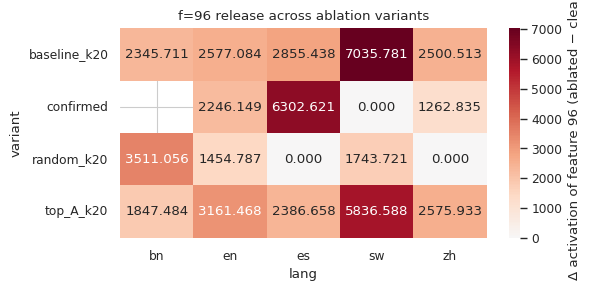

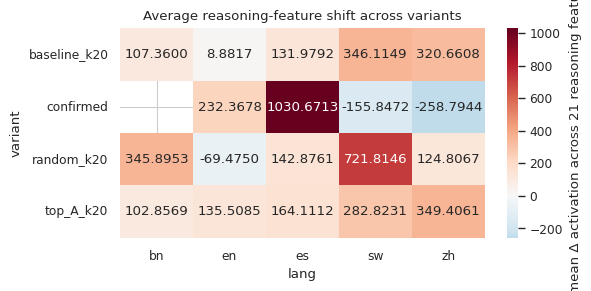

In [10]:
FIG_DIR = Path('results/figures'); FIG_DIR.mkdir(exist_ok=True, parents=True)
sns.set_theme(style='whitegrid', context='paper')

# Heatmap: f96 delta per (variant, lang). The headline question lives here.
if 'f96_delta' in summary_df.columns:
    pivot = summary_df.pivot(index='variant', columns='lang', values='f96_delta')
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                cbar_kws={'label': 'Δ activation of feature 96 (ablated − clean)'}, ax=ax)
    ax.set_title('f=96 release across ablation variants')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig14_controls_f96.png', dpi=150)
    plt.show()

# Heatmap: avg mean_delta across all 21 reasoning features per (variant, lang)
pivot2 = summary_df.pivot(index='variant', columns='lang', values='mean_delta_avg')
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pivot2, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'mean Δ activation across 21 reasoning features'}, ax=ax)
ax.set_title('Average reasoning-feature shift across variants')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_controls_avg.png', dpi=150)
plt.show()

## 7. Save

In [11]:
payload = {
    'config': {
        'primary_layer': PRIMARY_LAYER, 'n_dev': N_DEV, 'best_k': best_k,
        'reasoning_features_l17': REASONING_FEATS_L17,
    },
    'variants': {vname: {l: df.to_dict('records') for l, df in vsum.items()}
                  for vname, vsum in all_results.items()},
    'variant_inputs': {vname: dict(vdict) for vname, vdict in VARIANTS.items()},
    'curated_review': dict(LANGUAGE_CURATED),
    'summary_table': summary_df.to_dict('records'),
}
out = RESULTS_DIR / 'phase3a_controls.pt'
torch.save(payload, out)
print(f'Saved {out} ({out.stat().st_size/1e6:.1f} MB)')
if DRIVE_RESULTS is not None:
    torch.save(payload, DRIVE_RESULTS / 'phase3a_controls.pt')

print('\n=== HEADLINE QUESTION ===')
print('Does ablating CONFIRMED-only or CURATED features release feature 96 the way the BASELINE k=20 set did?')
if 'f96_delta' in summary_df.columns:
    print(summary_df[['variant','lang','f96_clean','f96_ablated','f96_delta','f96_p']]
          .pivot(index='variant', columns='lang', values='f96_delta').round(3).to_string())

Saved /workspace/nlp-project/results/phase3a_controls.pt (0.0 MB)

=== HEADLINE QUESTION ===
Does ablating CONFIRMED-only or CURATED features release feature 96 the way the BASELINE k=20 set did?
lang                bn        en        es        sw        zh
variant                                                       
baseline_k20  2345.711  2577.084  2855.438  7035.781  2500.513
confirmed          NaN  2246.149  6302.621     0.000  1262.835
random_k20    3511.056  1454.787     0.000  1743.721     0.000
top_A_k20     1847.484  3161.468  2386.658  5836.588  2575.933
